In [1]:
from pathlib import Path
from l1trigger_datamaker.h5convert import root2h5

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
pu_run386554 = pd.read_csv('/data/deodagiu/l1trigger_datamaker/l1trigger_datamaker/h5convert/pileup_files/run386554_brilcalc_PU', skiprows=1)[:-3]
pu_run386554['ls'] = pu_run386554["ls"].astype(str).str.split(":").str[0].astype(int)

pu_run386554['ls']

0          1
1          2
2          3
3          4
4          5
        ... 
1306    1307
1307    1308
1308    1309
1309    1310
1310    1311
Name: ls, Length: 1311, dtype: int64

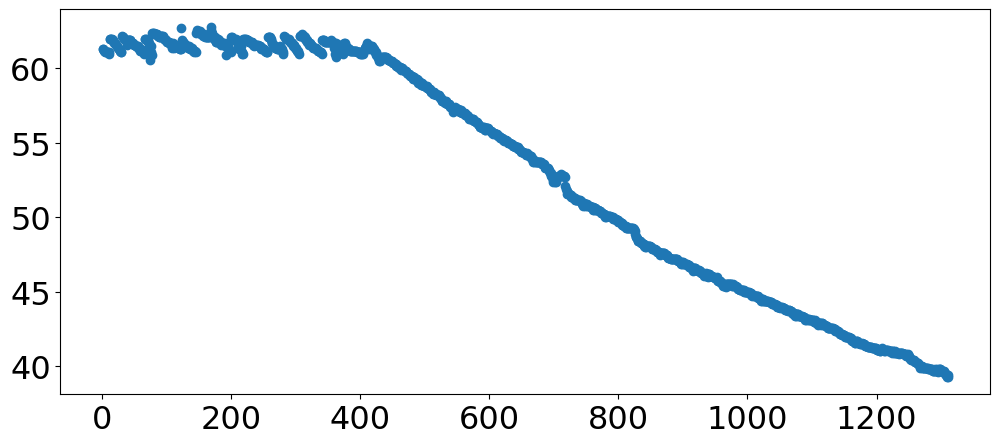

In [24]:
plt.figure(figsize=(12,5))
plt.scatter(pu_run386554['ls'], pu_run386554['avgpu'])
plt.show()

In [25]:
folder = Path("/data/deodagiu/ad_data/EZB-Run3-v1-RunI_dataRun3_Run3Winter-142X_250213_152003/")
reader = root2h5.Root2h5()
h5file = reader.read_folder(folder)
print(reader.energies.keys())
print(reader.particles.keys())
print(reader.event_info.items())

Reading folder of h5 files /data/deodagiu/ad_data/EZB-Run3-v1-RunI_dataRun3_Run3Winter-142X_250213_152003...
dict_keys(['ET', 'HT', 'MET', 'MHT', 'FET', 'FHT'])
dict_keys(['muons', 'jets', 'egammas', 'taus'])
dict_items([('event_info', ['run', 'lumi', 'event', 'bx', 'orbit', 'time', 'nPV_True', 'PU'])])


In [26]:
pileup = h5file["event_info"][:, -1]
towers = h5file["HT"][:, 0, 1]

In [27]:
plt.rc("xtick", labelsize=23)
plt.rc("ytick", labelsize=23)
plt.rc("axes", titlesize=25)
plt.rc("axes", labelsize=25)
plt.rc("legend", fontsize=22)

(2926798,)


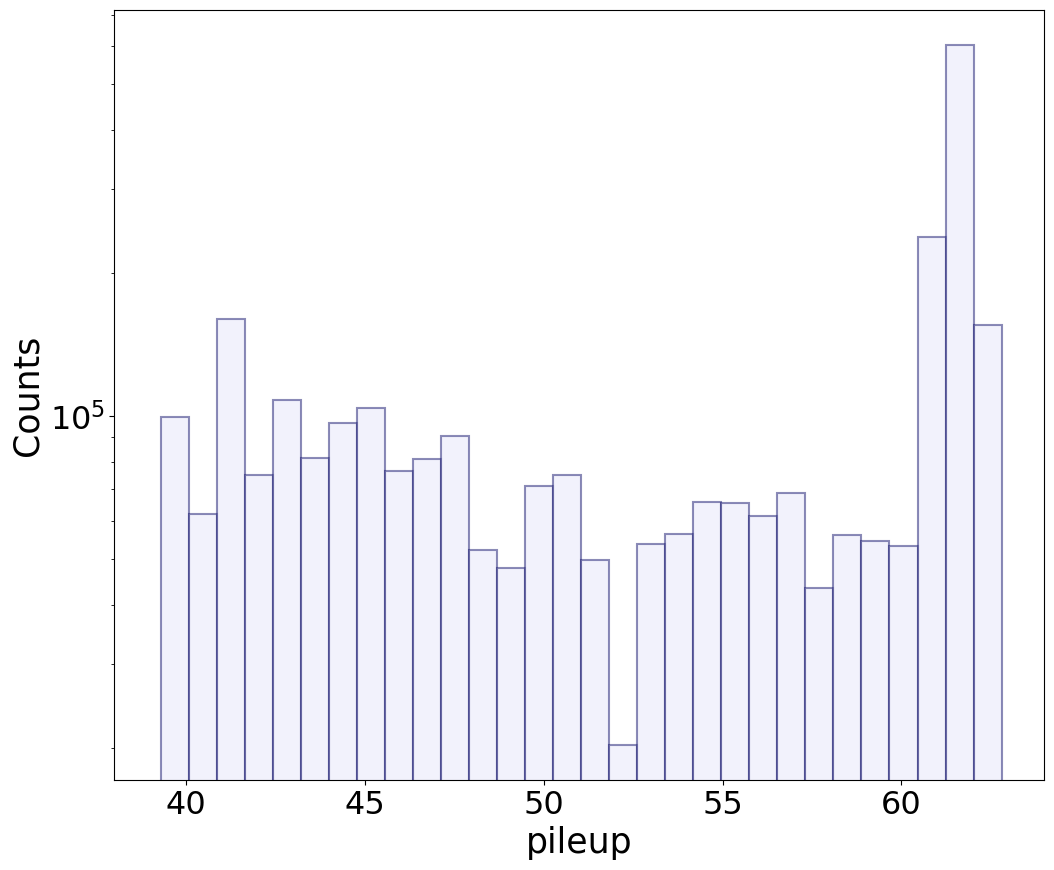

In [28]:
print(pileup[pileup > 0.1].shape)
plt.figure(figsize=(12, 10))
plt.xlim(38, 64)
plt.hist(
    x=np.array(pileup[pileup > 0.1]).flatten(),
    bins=30,
    alpha=0.5,
    linewidth=1.5,
    color="lavender",
    edgecolor="midnightblue",
)
plt.xlabel("pileup")
plt.ylabel("Counts")
plt.gca().set_yscale("log")

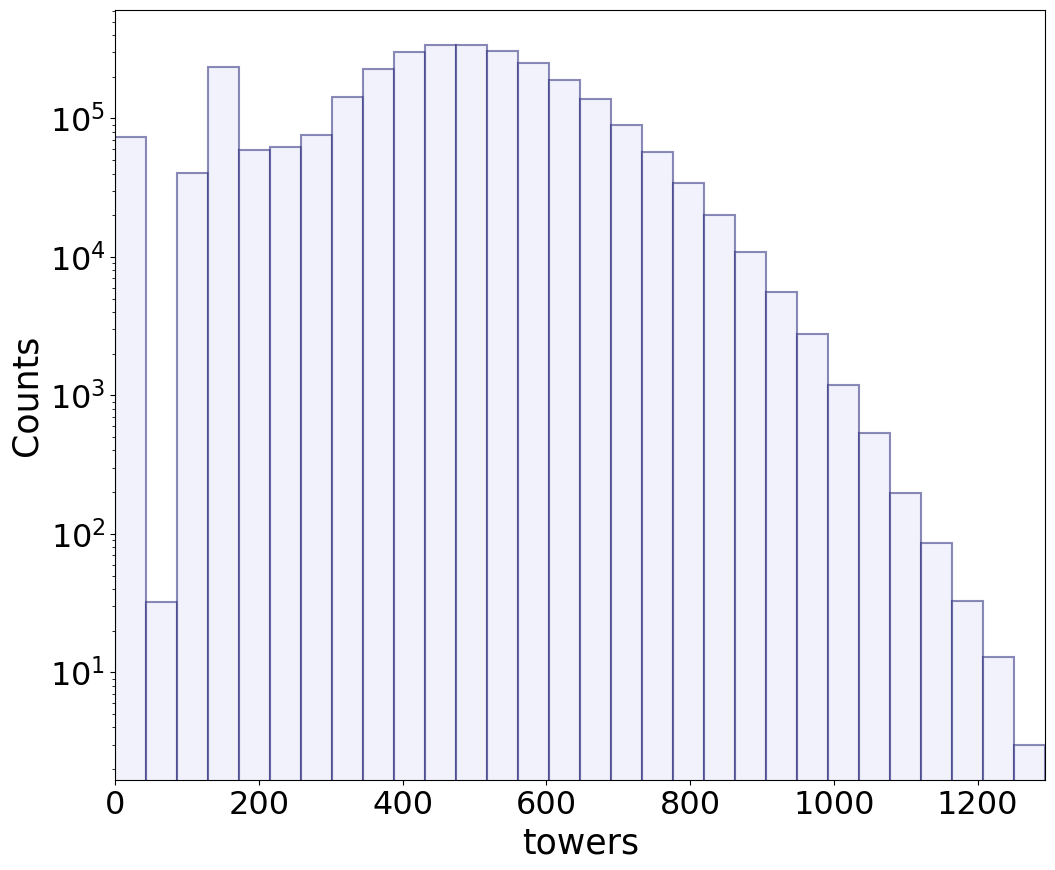

In [29]:
plt.figure(figsize=(12, 10))
plt.xlim(np.nanmin(towers), np.nanmax(towers))
plt.hist(
    x=np.array(towers).flatten(),
    bins=30,
    alpha=0.5,
    linewidth=1.5,
    color="lavender",
    edgecolor="midnightblue",
)
plt.xlabel("towers")
plt.ylabel("Counts")
plt.gca().set_yscale("log")

In [30]:
pileup = h5file["event_info"][:, -1]
towers = h5file["HT"][:, 0, 1]

In [31]:
towers_nans = np.argwhere(np.isnan(towers))
pileup_nans = np.argwhere(np.isnan(pileup))
print(towers_nans)
print(pileup_nans)

nans = set(np.append(towers_nans.flatten(), pileup_nans.flatten()))
print(nans)

pileup = np.delete(pileup, list(nans))
towers = np.delete(towers, list(nans))

[[201]]
[]
{201}


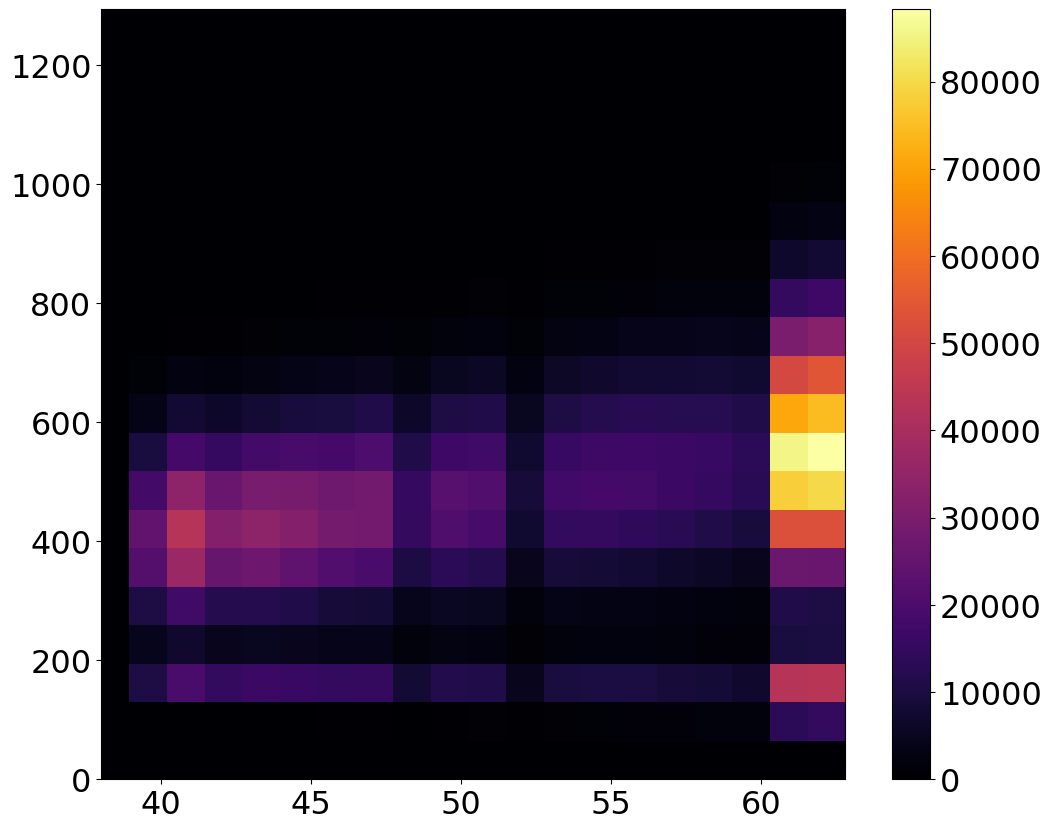

In [56]:
plt.figure(figsize=(12, 10))
counts, xedges, yedges, im = plt.hist2d(np.array(pileup).flatten(), np.array(towers).flatten(), bins=[50, 20], cmap='inferno')
plt.xlim(38, np.nanmax(pileup))
plt.ylim(np.nanmin(towers), np.nanmax(towers))
plt.colorbar(im)